In [1]:
# Install dependencies
%pip install ultralytics
%pip install opencv-python
%pip install simple_pid
%pip install numpy
%pip install pyserial
%pip install cv2-enumerate-cameras
%pip install scikit-learn
%pip install nolds

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Configurations
import cv2
import math
import serial
import time
import numpy as np
import nolds
import requests
from ultralytics import YOLO
from simple_pid import PID
from cv2_enumerate_cameras import enumerate_cameras
from collections import deque
from sklearn.decomposition import PCA

# Camera configuration
CAMERA_INDEX_1 = 1200                  # Index of the camera  to be used (custom value; check with enumerate_cameras)
CAMERA_INDEX_2 = 1201                  # Index of the camera to be used (custom value; check with enumerate_cameras)

# Movement vector filtering
VECTOR_MIN_LENGTH = 20                 # Minimum length of movement vector to consider (in pixels)
VECTOR_MAX_LENGTH = 200                # Maximum length of movement vector to consider (in pixels)
PIXELS_PER_UNIT = 200.0                # Conversion factor from pixels to real-world units (e.g., cm)
VECTOR_HISTORY_SIZE = 10                # Number of previous positions to store for movement vector calculation

# Geometry setup
CAMERA_DISTANCE = 43                   # Distance between two cameras (used for triangulation)
DISTANCE_UNIT = "cm"                   # Unit of measurement for camera distance

# YOLO model setup
MODEL = YOLO('yolov10m.pt')            # Load YOLOv8 nano model for object detection
CLASS_NAMES = MODEL.names              # List of all class labels in the model
DESIRED_CLASSES = ["sports ball"]      # Classes we want to detect (only track sports balls)

# PID control parameters
PID_KP = 0.015                         # PID Proportional gain
PID_KI = 0.003                         # PID Integral gain
PID_KD = 0.09                          # PID Derivative gain
PID_OUTPUT_LIMITS = (-3, 3)            # Output limits for PID correction to smooth servo movement
ALPHA = 0.2                            # Smoothing factor for servo movement (0 < ALPHA < 1)


# Servo configuration
SERVO_MIN = 0                          # Minimum angle a servo can rotate to
SERVO_MAX = 180                        # Maximum angle a servo can rotate to
SERVO_INIT = {                         # Initial servo positions (centered)
    'x1': 65, 
    'y1': 90, 
    'x2': 115, 
    'y2': 90
}

# Arduino serial communication
ARDUINO_PORT = '/dev/cu.usbmodem11301'  # Serial port where Arduino is connected
ARDUINO_BAUDRATE = 9600                 # Communication speed between Python and Arduino


# Telegram bot configuration
TOKEN = "8750939695:AAHakcI-1T_IC6WkK2CvcPSsSsAT5hnzCrI" # Change to your bot token
CHAT_ID = "-4856182101"                  # Change to your chat ID
ALERT_COOLDOWN = 30                     # Seconds between alerts

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/nolds/datasets.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
# CV2 and camera settings

# Initialize camera
def init_camera(index, verbose=True):
    cap = cv2.VideoCapture(index)
    if not cap.isOpened():
        raise RuntimeError(f"Error: Could not open webcam {index}.")
    if verbose:
        print(f"Camera {index} opened successfully.")
    return cap


# Read current frame
def read_frame(cap):
    ret, frame = cap.read()
    if not ret:
        raise RuntimeError("Failed to capture image from webcam.")
    return frame


# Calculate frame center
def calculate_center(frame):
    height, width = frame.shape[:2]
    x_center, y_center = width / 2, height / 2
    return x_center, y_center


# Check if class is in desired classes
def valid_class(box, class_names=CLASS_NAMES, desired_classes=DESIRED_CLASSES):
    return class_names[int(box.cls)] in desired_classes


# Draw bounding box
def draw_bounding_box(frame, box, class_names=CLASS_NAMES, verbose=True):
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 255), 3)
    
    cls = int(box.cls[0])
    confidence = math.ceil((box.conf[0] * 100)) / 100
    
    org = [x1, y1]
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 1
    color = (255, 0, 0)
    thickness = 2
    cv2.putText(frame, class_names[cls], org, font, font_scale, color, thickness)
    
    if verbose:
        print(f"Class: {class_names[cls]}, Confidence: {confidence}")


# Draw movement vector
def draw_movement_vector(frame, box, balloon_position, vector_history, avg_dt, prev_position=None, verbose=True):
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    cx_pixel, cy_pixel = int((x1 + x2) / 2), int((y1 + y2) / 2)
    x, y, z = float(balloon_position[0]), float(balloon_position[1]), float(balloon_position[2])

    if len(vector_history) == 0:
        base_px, base_py, base_pz = prev_position if prev_position is not None else (x, y, z)
    else:
        base_px = sum(p[0] for p in vector_history) / len(vector_history)
        base_py = sum(p[1] for p in vector_history) / len(vector_history)
        base_pz = sum(p[2] for p in vector_history) / len(vector_history)

    dx_w, dy_w, dz_w = x - base_px, y - base_py, z - base_pz
    mag_w = math.sqrt(dx_w**2 + dy_w**2 + dz_w**2)
    vel_w = mag_w / avg_dt

    if mag_w > 1e-9:
        ux, uy = dx_w / mag_w, dz_w / mag_w
        length_px = mag_w * PIXELS_PER_UNIT
        length_px = max(VECTOR_MIN_LENGTH, min(length_px, VECTOR_MAX_LENGTH))
        
        end_x = int(cx_pixel + ux * length_px)
        end_y = int(cy_pixel - uy * length_px)
        cv2.arrowedLine(frame, (cx_pixel, cy_pixel), (end_x, end_y), (0, 0, 255), 3, tipLength=0.3)

    vector_history.append((x, y, z))
    new_prev_position = (x, y, z)

    if verbose:
        print(f"3D displacement: ({dx_w:.3f}, {dy_w:.3f}, {dz_w:.3f})")
        print(f"Velocity: {vel_w:.3f} {DISTANCE_UNIT}/s")

    return new_prev_position

In [4]:
# Calculations

# Calculate balloon coordinates
def triangulation(angles: dict, d=CAMERA_DISTANCE, verbose=True):
    alpha = np.radians(angles['x1'])
    beta = np.radians(angles['x2']-90)
    gamma = np.radians(90-angles['y1'])
    delta = np.radians(90-angles['y2'])
    
    if (np.sin(alpha + beta)) == 0:
        raise ValueError("Invalid angles for triangulation.")
    
    n = d * np.sin(beta) / np.sin(alpha + beta)
    m = d * np.sin(alpha) / np.sin(alpha + beta)

    x1 = n * np.cos(alpha)
    y1 = n * np.sin(alpha)
    z1 = n * np.tan(gamma)
    
    x2 = d - (m * np.cos(beta))
    y2 = m * np.sin(beta)
    z2 = m * np.tan(delta)

    x = (x1 + x2) / 2
    y = (y1 + y2) / 2
    z = (z1 + z2) / 2
    
    if verbose:
        print(f"Balloon position: ({x:.2f}, {y:.2f}, {z:.2f})")
    
    return np.array([x, y, z])


# Calculate distance to camera
def get_distance(camera, balloon_position, d=CAMERA_DISTANCE, verbose=True):
    if camera == 'C1':
        camera_position = np.array([0, 0, 0])
    elif camera == 'C2':
        camera_position = np.array([d, 0, 0])
    else:
        raise ValueError("Invalid camera ID. Use 'C1' or 'C2'.")
    
    distance = np.linalg.norm(balloon_position - camera_position)
    
    if verbose:
        print(f"{camera} Distance: {distance:.2f} {DISTANCE_UNIT}")
    
    return distance


In [5]:
# Lyapunov exponent

def compute_lyapunov_exponent(positions, dt, method="pca", emb_dim=6, tau=1, min_tsep=10, trajectory_len=20, debug_plot=True):
    positions = np.array(positions)
    if positions.shape[1] != 3:
        raise ValueError("Positions must be of shape (N,3).")

    if method.lower() == "pca":
        pca = PCA(n_components=1)
        scalar_series = pca.fit_transform(positions).flatten()
    elif method.lower() == "norm":
        scalar_series = np.linalg.norm(positions, axis=1)
    elif method.lower() in ["x", "y", "z"]:
        idx = {"x":0, "y":1, "z":2}[method.lower()]
        scalar_series = positions[:, idx]
    else:
        raise ValueError("Invalid method. Choose 'pca', 'norm', 'x', 'y', or 'z'.")

    scalar_series = (scalar_series - np.mean(scalar_series)) / (np.std(scalar_series) + 1e-12)

    lyap_raw = nolds.lyap_r(
        scalar_series,
        emb_dim=emb_dim,
        tau=tau,
        min_tsep=min_tsep,
        trajectory_len=trajectory_len,
        debug_plot=debug_plot
    )
    lyap_exp = lyap_raw / dt
    lyap_time = 1 / lyap_exp if lyap_exp > 0 else float('inf')

    return lyap_exp, lyap_time

In [6]:
# PID controller

# Initialize PID controller
def init_pid(x_center, y_center, verbose=True):
    global prev_pan, prev_tilt
    prev_pan, prev_tilt = 0, 0
    pid_pan = PID(Kp=PID_KP, Ki=PID_KI, Kd=PID_KD, setpoint=x_center)
    pid_pan.output_limits = PID_OUTPUT_LIMITS
    pid_tilt = PID(Kp=PID_KP, Ki=PID_KI, Kd=PID_KD, setpoint=y_center)
    pid_tilt.output_limits = PID_OUTPUT_LIMITS
    if verbose:
        print("PID controller initialized.")
    return pid_pan, pid_tilt


# Calculate corrections using PID controller
def calculate_corrections(box, pid_pan, pid_tilt, verbose=True):
    global prev_pan, prev_tilt
    x1, y1, x2, y2 = box.xyxy[0]
    x_box = float((x1 + x2) / 2)
    y_box = float((y1 + y2) / 2)
    
    pan_raw = pid_pan(x_box)
    tilt_raw = pid_tilt(y_box)
    pan = ALPHA * pan_raw + (1 - ALPHA) * prev_pan
    tilt = ALPHA * tilt_raw + (1 - ALPHA) * prev_tilt
    prev_pan, prev_tilt = pan, tilt
    
    if verbose:
        print(f"Box: ({x_box}, {y_box})")
        print(f"Pan: {pan}, Tilt: {tilt}")
    return pan, tilt


# Update servo angle
def update_angle(servo_angle, correction):
    if correction > 10:
        correction = 10
    elif correction < -10:
        correction = -10
    return max(SERVO_MIN, min(SERVO_MAX, math.ceil(servo_angle + correction)))

In [7]:
# Arduino

# Initialize serial connection to arduino
def init_arduino(*, port=ARDUINO_PORT, baudrate=ARDUINO_BAUDRATE, initial_angles=SERVO_INIT, verbose=True):
    try:
        arduino = serial.Serial(port, baudrate)
        time.sleep(2)
        if verbose:
            print(f"Connected to Arduino on {port} at {baudrate} baud.")
        move_servos(arduino, initial_angles)
        return arduino
    except serial.SerialException as e:
        raise RuntimeError(f"Could not connect to Arduino on {port}: {e}")


# Move servos
def move_servos(arduino, angles: dict, verbose=True):
    try:
        command = f"{angles['x1']},{angles['y1']},{angles['x2']},{angles['y2']}\n"
        arduino.write(command.encode())
        arduino.flush()
        if verbose:
            print(f"C1 → X: {angles['x1']:.1f}°, Y: {angles['y1']:.1f}°")
            print(f"C2 → X: {angles['x2']:.1f}°, Y: {angles['y2']:.1f}°")
            
    except serial.SerialException as e:
        print(f"Serial communication error: {e}")

In [8]:
# Telegram alert

def send_telegram_alert(position, dist_c1, dist_c2, message="🎈 Balão detectado!"):
    global last_alert_time
    now = time.time()
    
    if now - last_alert_time >= ALERT_COOLDOWN:
        x, y, z = position
        message = f"🎈 Balão detectado!\n" \
                f"📍 Coordenadas: x={x:.2f}, y={y:.2f}, z={z:.2f}\n"
        
        if dist_c1 is not None:
            message += f"📏 Distância C1: {dist_c1:.2f} cm\n"
        if dist_c2 is not None:
            message += f"📏 Distância C2: {dist_c2:.2f} cm\n"

        url = f"https://api.telegram.org/bot{TOKEN}/sendMessage"
        data = {"chat_id": CHAT_ID, "text": message}
        response = requests.post(url, data=data)
        
        if response.status_code == 200:
            print("📩 Coordenadas enviadas com sucesso!")
        else:
            print("⚠️ Erro ao enviar coordenadas:", response.text)
        
        last_alert_time = now

In [9]:
# Print functions

# Print divider
def print_div(text):
    print("\n" + f" {text} ".center(100, '-') + "\n")


# Print available cameras
def print_cameras():
    for camera_info in enumerate_cameras():
        print(f'{camera_info.index}: {camera_info.name}')


# Print final information
def final_prints(frame_count, x1_center, y1_center, x2_center, y2_center, frame_delay, balloon_position, dist_c1, dist_c2, servo_angles, lyap_exp, lyap_time):
    x, y, z = balloon_position
    print(f"Total frames: {frame_count}, Total time: {frame_delay*frame_count:.2f} seconds")
    print(f"Detected classes: {DESIRED_CLASSES}")
    print(f"Frame centers: ({x1_center}, {y1_center}), ({x2_center}, {y2_center})")
    print(f"FPS: {(1/frame_delay):.2f}")
    print(f"Final balloon position: ({x:.2f}, {y:.2f}, {z:.2f})")
    print(f"Final C1 distance: {dist_c1:.2f} {DISTANCE_UNIT}")
    print(f"Final C2 distance: {dist_c2:.2f} {DISTANCE_UNIT}")
    print(f"Servo angles: {servo_angles}")
    print(f"Lyapunov exponent: {lyap_exp:.4f} per second")
    if lyap_time != float('inf'):
        print(f"Predictability horizon: {lyap_time:.2f} seconds\n")
    else:
        print("Predictability horizon: Infinite (non-chaotic behavior)\n")


---------------------------------------- Available cameras -----------------------------------------

1200: USB Camera VID:1133 PID:2085
1201: C270 HD WEBCAM
1202: iPhone Leo Camera
1203: MacBook Air Camera

----------------------------------------- Initial settings -----------------------------------------

Connected to Arduino on /dev/cu.usbmodem11301 at 9600 baud.
C1 → X: 65.0°, Y: 90.0°
C2 → X: 115.0°, Y: 90.0°
Camera 1200 opened successfully.
Camera 1201 opened successfully.
PID controller initialized.
PID controller initialized.

----------------------------------------- Program started ------------------------------------------

Frame number: 0
Balloon position: (7.68, 16.47, 0.00)
C1 Distance: 18.17 cm
C2 Distance: 38.97 cm
Servo angles: {'x1': 65, 'y1': 90, 'x2': 115, 'y2': 90}

0: 480x640 5 persons, 2 chairs, 1 dining table, 1 laptop, 188.2ms
Speed: 2.2ms preprocess, 188.2ms inference, 0.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 7 persons, 1 bottle, 4 c

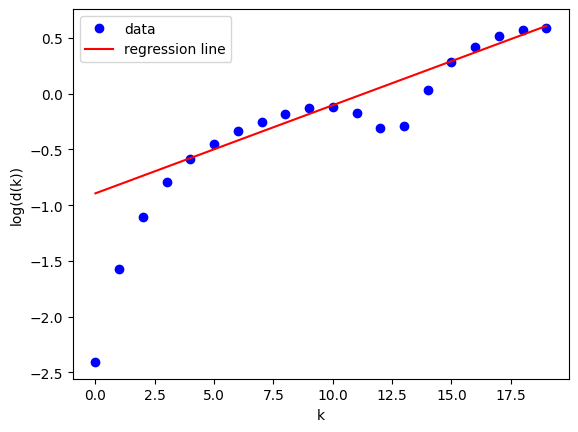

Total frames: 306, Total time: 94.97 seconds
Detected classes: ['sports ball']
Frame centers: (640.0, 480.0), (640.0, 480.0)
FPS: 3.22
Final balloon position: (-31.80, 110.89, 38.91)
Final C1 distance: 121.75 cm
Final C2 distance: 139.31 cm
Servo angles: {'x1': 106, 'y1': 70, 'x2': 146, 'y2': 75}
Lyapunov exponent: 0.2549 per second
Predictability horizon: 3.92 seconds



: 

In [ ]:
# Main program
print_div("Available cameras")
print_cameras()

print_div("Initial settings")
frame_count, total_time, last_alert_time = 0, 0, 0
prev_time = time.time()

SERVO_INIT = {'x1': 65, 'y1': 90, 'x2': 115, 'y2': 90}
servo_angles = SERVO_INIT
vector_history = deque(maxlen=VECTOR_HISTORY_SIZE)
prev_position = None
balloon_positions_history = []

arduino = init_arduino(initial_angles=servo_angles)
cap1 = init_camera(CAMERA_INDEX_1)
cap2 = init_camera(CAMERA_INDEX_2)
frame1 = read_frame(cap1)
frame2 = read_frame(cap2)
x1_center, y1_center = calculate_center(frame1)
x2_center, y2_center = calculate_center(frame2)

pid_pan1, pid_tilt1 = init_pid(x1_center, y1_center)
pid_pan2, pid_tilt2 = init_pid(x2_center, y2_center)

print_div("Program started")
try:
    while True:
        print(f"Frame number: {frame_count}")
        current_time = time.time()
        frame_delay = current_time - prev_time
        total_time += frame_delay
        avg_frame_delay = total_time / frame_count if frame_count > 0 else frame_delay
        prev_time = current_time
            
        balloon_position = triangulation(servo_angles)
        balloon_positions_history.append(balloon_position.copy())
        dist_c1 = get_distance('C1', balloon_position)
        dist_c2 = get_distance('C2', balloon_position)
        print(f"Servo angles: {servo_angles}")
        
        x1_correction, y1_correction = 0, 0
        frame1 = read_frame(cap1)
        results1 = MODEL(frame1, stream=True)
        for r1 in results1:
            if not r1.boxes:
                continue
            for box1 in r1.boxes:
                if valid_class(box1):
                    draw_bounding_box(frame1, box1)
                    prev_position = draw_movement_vector(frame1, box1, balloon_position, vector_history, avg_frame_delay, prev_position)
                    x1_correction, y1_correction = calculate_corrections(box1, pid_pan1, pid_tilt1)
                    send_telegram_alert(balloon_position, dist_c1, dist_c2)
        
        x2_correction, y2_correction = 0, 0
        frame2 = read_frame(cap2)
        results2 = MODEL(frame2, stream=True)
        for r2 in results2:
            if not r2.boxes:
                continue
            for box2 in r2.boxes:
                if valid_class(box2):
                    draw_bounding_box(frame2, box2)
                    prev_position = draw_movement_vector(frame2, box2, balloon_position, vector_history, avg_frame_delay, prev_position)
                    x2_correction, y2_correction = calculate_corrections(box2, pid_pan2, pid_tilt2)
                    send_telegram_alert(balloon_position, dist_c1, dist_c2)
                
        c1_change = x1_correction != 0 or y1_correction != 0
        c2_change = x2_correction != 0 or y2_correction != 0
        
        if c1_change:
            y1_correction *= -1 # type: ignore
            servo_angles['x1'] = update_angle(servo_angles['x1'], x1_correction)
            servo_angles['y1'] = update_angle(servo_angles['y1'], y1_correction)
        
        if c2_change:
            y2_correction *= -1 # type: ignore
            servo_angles['x2'] = update_angle(servo_angles['x2'], x2_correction)
            servo_angles['y2'] = update_angle(servo_angles['y2'], y2_correction)
        
        if c1_change or c2_change:
            move_servos(arduino, servo_angles)
        
        cv2.imshow("Image1", frame1)
        cv2.imshow("Image2", frame2)
        if cv2.waitKey(1) == ord('q'):
            break
        frame_count += 1
finally:
    print_div("Program finished")
    lyap_exp, lyap_time = compute_lyapunov_exponent(balloon_positions_history, avg_frame_delay)
    final_prints(frame_count, x1_center, y1_center, x2_center, y2_center, avg_frame_delay, 
                 balloon_position, dist_c1, dist_c2, servo_angles, lyap_exp, lyap_time)
    cap1.release()
    cap2.release()
    cv2.destroyAllWindows()
    arduino.close()

In [ ]:
enumerate_cameras()

[1200: C270 HD WEBCAM (046D:0825),
 1201: USB Camera VID:1133 PID:2085 (046D:0825),
 1202: MacBook Air Camera]